# 02 · 情感分析（中文 BERT）

**方法**：`uer/roberta-base-finetuned-dianping-chinese`（102M，二分类 negative/positive），
取 `p_pos` 后用中性带切三类，保持与原图「正面/负面/中性」的视觉口径一致。

**原 notebook 无情感方法可沿用**：`比赛.ipynb` 里的 `[352, 287, 361]` 是硬编码常量，
不存在可复现的计算过程。本 notebook 是新建的真实计算。

### 三层样本

| 层 | 定义 | 条数 | 用途 |
|---|---|---|---|
| **主结果** | 2023+ 且提及品类核心词 | 260 | 报告引用 |
| 对照 A | 2023+ 全量（含离题） | 523 | 量化爬虫噪声的影响 |
| 对照 B | 全量 2012-2025 | 881 | 长期背景 |

**为什么要筛相关集**：MediaCrawler 按关键词抓「视频/帖子」，再抓该帖**整个评论区**，
评论区跑题的内容（奶茶店推荐、游戏讨论、京东广告灌水）会一并入库。
2023+ 里有 50.3% 的评论完全不提王老吉/凉茶/加多宝/上火等任何品类核心词。

### 两点已知局限

1. **模型有负面偏置**：在大众点评评论上微调，对陈述句/怀旧句倾向判负面。
   例：「怕上火喝王老吉，这广告我背了二十年」→ `p_pos = 0.010`。
2. **中性带高度敏感**：阈值从 [0.45,0.55] 到 [0.25,0.75]，中性占比会从 5% 变到 33%。
   可靠的是**类别排序与平台差异**，不是具体百分点。下面会做敏感性检验。

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
warnings.filterwarnings('ignore')

PROJ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJ / 'src'))
import text_utils as T

PROC = PROJ / 'data' / 'processed'
FIG  = PROJ / 'outputs' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

# 中文字体：跨平台探测 + 回退（原 notebook 硬编码 SimHei 路径）
font = T.get_cjk_font(verbose=True)          # 跨平台中文字体，含回退
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(PROC / 'comments_clean.csv', encoding='utf-8-sig', parse_dates=['created_at'])
df['year']     = df['created_at'].dt.year
df['recent']   = df['year'] >= 2023
df['on_topic'] = df['content_clean'].map(T.is_on_topic)
df['is_primary'] = df['recent'] & df['on_topic']          # 主结果

print('品类核心词 :', T.CORE_TERMS)
print()
print('全量 (对照B)          :', len(df), '条')
print('2023+ 全量 (对照A)    :', int(df['recent'].sum()), '条')
print('2023+ 相关集 (主结果) :', int(df['is_primary'].sum()), '条')
print()
print('=== 离题率 ===')
g = df.groupby('recent')['on_topic'].agg(['size', 'sum'])
g['离题条数'] = g['size'] - g['sum']
g['离题率%'] = ((1 - g['sum'] / g['size']) * 100).round(1)
g.index = ['2012-2022', '2023+']
print(g.rename(columns={'size': '总数', 'sum': '相关条数'}).to_string())

中文字体: SimHei
品类核心词 : ['王老吉', '凉茶', '加多宝', '和其正', '国际罐', 'WALOVI', '上火', '降火', '怕上火', '红罐', '草本', '广药', '鸿道']

全量 (对照B)          : 881 条
2023+ 全量 (对照A)    : 523 条
2023+ 相关集 (主结果) : 260 条

=== 离题率 ===
            总数  相关条数  离题条数  离题率%
2012-2022  358   219   139  38.8
2023+      523   260   263  50.3


## 1. 模型推理

对全部 881 条算一次 `p_pos`，三层共用，避免重复计算。

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL = 'uer/roberta-base-finetuned-dianping-chinese'
tok = AutoTokenizer.from_pretrained(MODEL)
mdl = AutoModelForSequenceClassification.from_pretrained(MODEL).eval()
print('模型 :', MODEL)
print('标签 :', mdl.config.id2label)

texts = df['content_clean'].astype(str).tolist()
probs, BS = [], 32
with torch.no_grad():
    for i in range(0, len(texts), BS):
        batch = tok(texts[i:i + BS], return_tensors='pt', padding=True,
                    truncation=True, max_length=256)
        probs.extend(torch.softmax(mdl(**batch).logits, dim=-1)[:, 1].tolist())

df['p_pos'] = probs
n_trunc = sum(len(tok(t)['input_ids']) > 256 for t in texts)
print()
print('推理完成                 :', len(probs), '条')
print('因超长被截断(>256 token) :', n_trunc, '条')
print('p_pos 分布 :', df['p_pos'].describe()[['min', '25%', '50%', '75%', 'max']].round(3).to_dict())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

模型 : uer/roberta-base-finetuned-dianping-chinese
标签 : {0: 'negative (stars 1, 2 and 3)', 1: 'positive (stars 4 and 5)'}



推理完成                 : 881 条
因超长被截断(>256 token) : 4 条
p_pos 分布 : {'min': 0.004, '25%': 0.074, '50%': 0.326, '75%': 0.705, 'max': 0.993}


## 2. 定中性带 + 敏感性检验

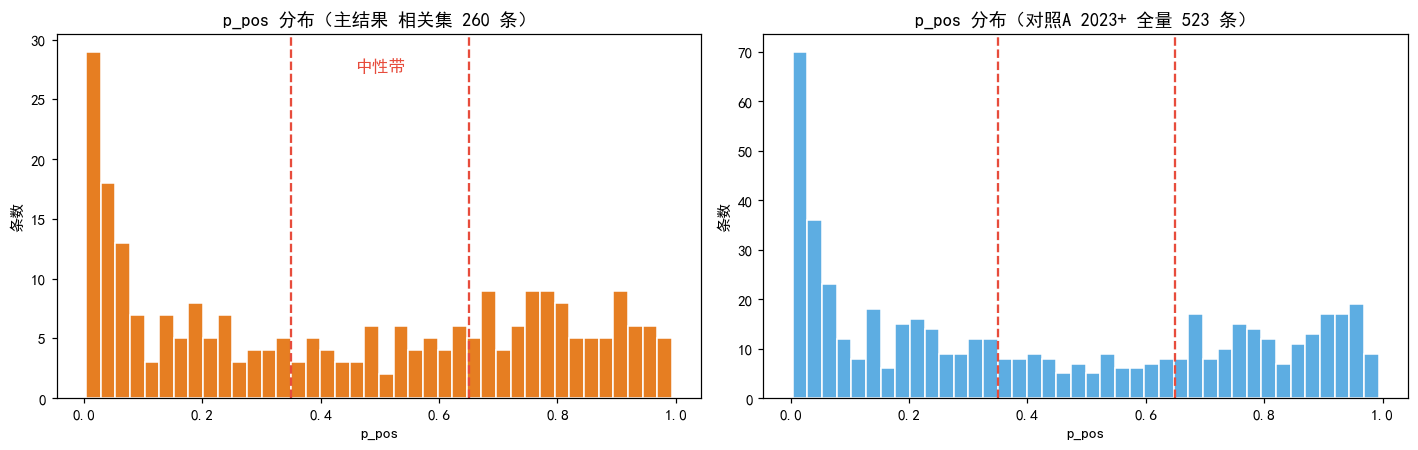

主结果落在 [0.35, 0.65] 的比例 : 19.6%

=== 中性带敏感性检验（主结果 相关集 260 条）===
         中性带  正面%  负面%  中性%
[0.45, 0.55] 42.3 51.2  6.5
  [0.4, 0.6] 38.8 48.5 12.7
[0.35, 0.65] 35.0 45.4 19.6
  [0.3, 0.7] 29.6 41.9 28.5
[0.25, 0.75] 25.4 39.2 35.4

采用中性带 [0.35, 0.65]


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for a, (mask, ttl, col) in zip(ax, [
        (df['is_primary'], 'p_pos 分布（主结果 相关集 260 条）', '#E67E22'),
        (df['recent'],     'p_pos 分布（对照A 2023+ 全量 523 条）', '#5DADE2')]):
    a.hist(df.loc[mask, 'p_pos'], bins=40, color=col, edgecolor='white')
    a.set_title(ttl, fontproperties=font, fontsize=12)
    a.set_xlabel('p_pos', fontproperties=font)
    a.set_ylabel('条数', fontproperties=font)
    for b in (0.35, 0.65):
        a.axvline(b, color='#E74C3C', ls='--', lw=1.5)
ax[0].text(0.5, ax[0].get_ylim()[1] * 0.9, '中性带', ha='center',
           fontproperties=font, color='#E74C3C', fontsize=11)
plt.tight_layout()
plt.savefig(FIG / '02_ppos_distribution.png', bbox_inches='tight')
plt.show()

print('主结果落在 [0.35, 0.65] 的比例 :',
      f"{df.loc[df['is_primary'], 'p_pos'].between(0.35, 0.65).mean() * 100:.1f}%")


def label3(p, lo, hi):
    return np.where(p < lo, '负面', np.where(p > hi, '正面', '中性'))


print()
print('=== 中性带敏感性检验（主结果 相关集 260 条）===')
rows = []
for lo, hi in [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65), (0.30, 0.70), (0.25, 0.75)]:
    vc = pd.Series(label3(df.loc[df['is_primary'], 'p_pos'].values, lo, hi)) \
           .value_counts(normalize=True) * 100
    rows.append({'中性带': f'[{lo}, {hi}]',
                 '正面%': round(vc.get('正面', 0), 1),
                 '负面%': round(vc.get('负面', 0), 1),
                 '中性%': round(vc.get('中性', 0), 1)})
print(pd.DataFrame(rows).to_string(index=False))

LO, HI = 0.35, 0.65          # 采用值
df['sentiment'] = label3(df['p_pos'].values, LO, HI)
print()
print(f'采用中性带 [{LO}, {HI}]')

## 3. 人工抽检（主结果内）

模型有负面偏置，抽样核对以便判断可信度。

片段仅用于方法说明，已截断至 40 字并去除所有标识信息，不指向具体用户。

In [4]:
for lab in ['正面', '中性', '负面']:
    sub = df[(df['sentiment'] == lab) & df['is_primary']].nlargest(4, 'n_tokens')
    print('=' * 74)
    print(f'【{lab}】主结果中抽 4 条')
    for _, r in sub.iterrows():
        print(f"  p_pos={r['p_pos']:.3f} | {r['content_clean'][:40]}")

【正面】主结果中抽 4 条
  p_pos=0.692 | 据说这是王老吉未来新产品威力加强版2 0名单 特别版 暖怀温王老吉 以红茶和红枣
  p_pos=0.937 | 喝WALOVI，与王老吉品牌全球代言人张凌赫一起，向世界传递东方健康理念！动动小
  p_pos=0.993 | 已三连 身为广东本地人 怎么能不去看全运会呢！非常凑巧的是柔道比赛场馆刚好在我家
  p_pos=0.731 | 商标是加多宝买的（有期限），但营销确实是人家做的，也的确赚钱了。本来加多宝是要给
【中性】主结果中抽 4 条
  p_pos=0.643 | 自以为是自己的广告词帮忙打了胜仗，其实是其他广告渠道占了王老吉的份额。他这种的自
  p_pos=0.594 | 还可以补充一种由外国进入当地的凉茶：“鬼佬凉茶”，可乐当初的确是一种感冒的药品，
  p_pos=0.638 | “而羊城药厂有着典型国企的样态，就是对于一些事情不拘小节，因为他觉得他最大。当时
  p_pos=0.507 | 记得2013年吧！加多宝和王老吉红罐之争，在我这里两家品牌商摆着摊位促销，王老吉
【负面】主结果中抽 4 条
  p_pos=0.203 | 第一次在广东喝凉茶，老板端上来的时候嘱咐我要一口喝完，我微笑谢过，转头小口品尝起
  p_pos=0.200 | 这事，分立场看，鸿道觉得，当初是我给你领养的孩子，要不是我，早完了，哪有你今天白
  p_pos=0.015 | 这个视频就像老太婆的裹脚布，又臭又长，反复的在那里强调什么心智之战，什么心智之战
  p_pos=0.220 | 可以这么说，全国除两广外其他省市号称爱喝凉茶的，起码超过九成没喝过真正的凉茶，别


## 4. 情感分布图

同一函数画三遍：主结果 / 对照A / 对照B。

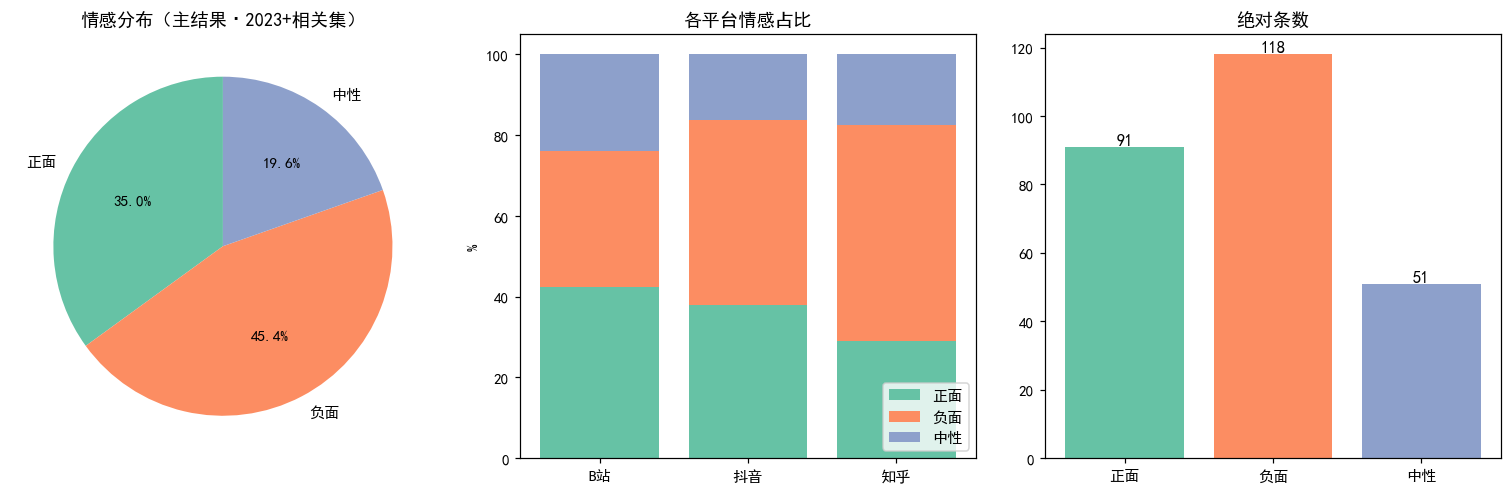

（主结果·2023+相关集） n = 260
            条数   占比%
sentiment           
正面          91  35.0
负面         118  45.4
中性          51  19.6

各平台情感占比 (%):
sentiment    正面    负面    中性
platform                   
B站         42.4  33.7  23.9
抖音         37.8  45.9  16.2
知乎         29.0  53.4  17.6


In [5]:
COLORS = {'正面': '#66c2a5', '负面': '#fc8d62', '中性': '#8da0cb'}
ORDER  = ['正面', '负面', '中性']


def plot_sentiment(sub, suffix, tag):
    vc = sub['sentiment'].value_counts().reindex(ORDER).fillna(0).astype(int)
    ct = pd.crosstab(sub['platform'], sub['sentiment']).reindex(columns=ORDER).fillna(0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    fig = plt.figure(figsize=(14, 4.6))

    a1 = fig.add_subplot(1, 3, 1)
    a1.pie(vc.values, labels=ORDER, colors=[COLORS[k] for k in ORDER],
           autopct='%1.1f%%', startangle=90, textprops={'fontproperties': font})
    a1.set_title('情感分布' + suffix, fontproperties=font, fontsize=12)

    a2 = fig.add_subplot(1, 3, 2)
    bottom = np.zeros(len(ct_pct))
    for k in ORDER:
        a2.bar(ct_pct.index, ct_pct[k], bottom=bottom, label=k, color=COLORS[k])
        bottom += ct_pct[k].values
    a2.set_title('各平台情感占比', fontproperties=font, fontsize=12)
    a2.set_ylabel('%', fontproperties=font)
    a2.set_xticks(range(len(ct_pct.index)))
    a2.set_xticklabels(ct_pct.index, fontproperties=font)
    a2.legend(prop=font, fontsize=9, loc='lower right')

    a3 = fig.add_subplot(1, 3, 3)
    for b in a3.bar(ORDER, vc.values, color=[COLORS[k] for k in ORDER]):
        a3.text(b.get_x() + b.get_width() / 2, b.get_height(), str(int(b.get_height())),
                ha='center', va='bottom', fontproperties=font, fontsize=11)
    a3.set_title('绝对条数', fontproperties=font, fontsize=12)
    a3.set_xticks(range(len(ORDER)))
    a3.set_xticklabels(ORDER, fontproperties=font)

    plt.tight_layout()
    plt.savefig(FIG / (tag + '.png'), bbox_inches='tight')
    plt.show()

    print(suffix, 'n =', len(sub))
    print(pd.DataFrame({'条数': vc, '占比%': (vc / vc.sum() * 100).round(1)}).to_string())
    print()
    print('各平台情感占比 (%):')
    print(ct_pct.round(1).to_string())


plot_sentiment(df[df['is_primary']], '（主结果·2023+相关集）', '02_sentiment_primary')

### 对照 A：2023+ 全量（含 50.3% 离题）

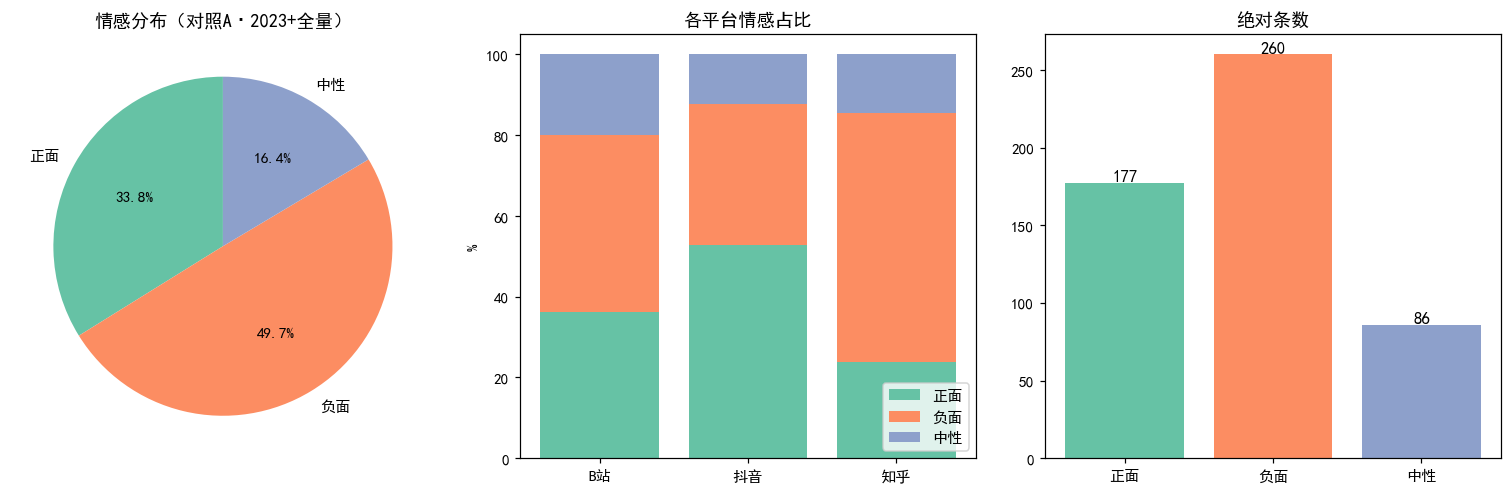

（对照A·2023+全量） n = 523
            条数   占比%
sentiment           
正面         177  33.8
负面         260  49.7
中性          86  16.4

各平台情感占比 (%):
sentiment    正面    负面    中性
platform                   
B站         36.3  43.7  20.0
抖音         52.8  34.8  12.4
知乎         23.7  61.6  14.6


In [6]:
plot_sentiment(df[df['recent']], '（对照A·2023+全量）', '02_sentiment_controlA_withnoise')

### 对照 B：全量 2012-2025

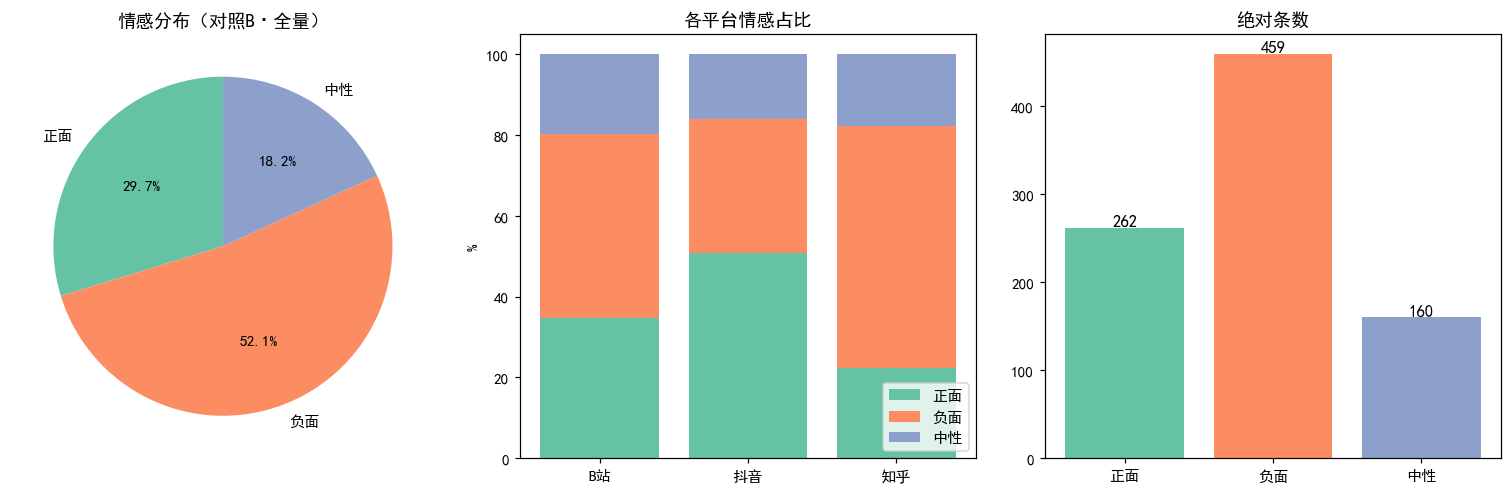

（对照B·全量） n = 881
            条数   占比%
sentiment           
正面         262  29.7
负面         459  52.1
中性         160  18.2

各平台情感占比 (%):
sentiment    正面    负面    中性
platform                   
B站         34.8  45.5  19.7
抖音         50.9  33.0  16.0
知乎         22.4  59.9  17.7


In [7]:
plot_sentiment(df, '（对照B·全量）', '02_sentiment_controlB_full')

## 5. 噪声影响：三层并列

直接看离题评论把结论推偏了多少。

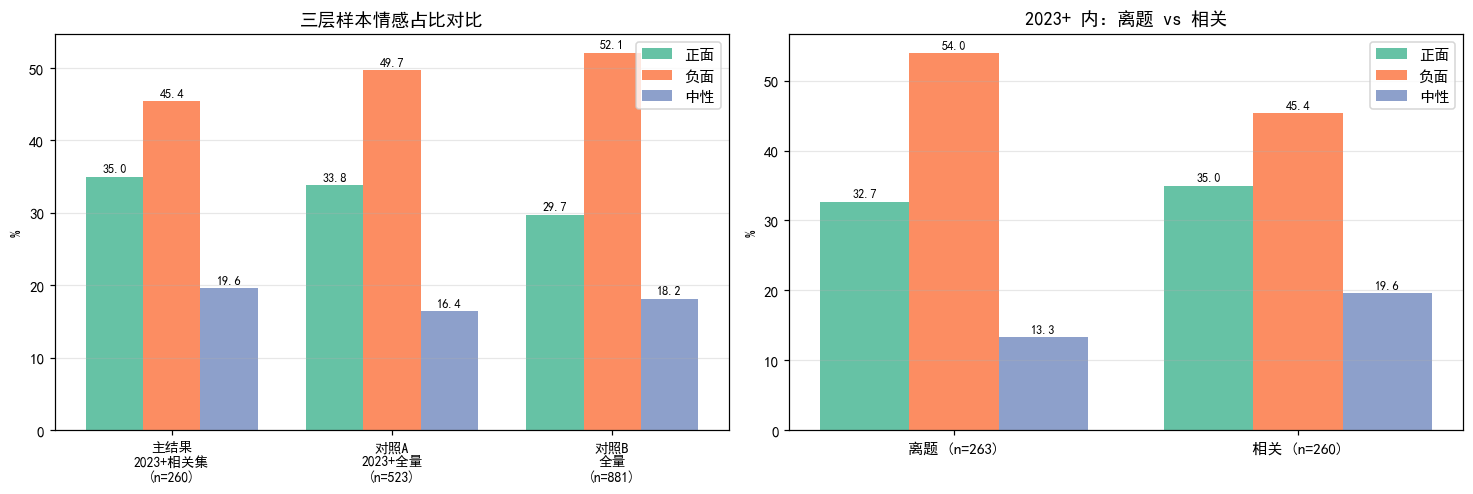

=== 三层情感占比 (%) ===
sentiment                 正面    负面    中性
主结果\n2023+相关集\n(n=260)  35.0  45.4  19.6
对照A\n2023+全量\n(n=523)   33.8  49.7  16.4
对照B\n全量\n(n=881)        29.7  52.1  18.2

=== 2023+ 内 离题 vs 相关 (%) ===
sentiment     正面    负面    中性
离题 (n=263)  32.7  54.0  13.3
相关 (n=260)  35.0  45.4  19.6

离题评论把负面率推高了 4.3 个百分点


In [8]:
_pri, _ctlA, _ctlB = df[df['is_primary']], df[df['recent']], df
layers = {
    f'主结果\n2023+相关集\n(n={len(_pri)})':  _pri,
    f'对照A\n2023+全量\n(n={len(_ctlA)})':    _ctlA,
    f'对照B\n全量\n(n={len(_ctlB)})':         _ctlB,
}
mat = pd.DataFrame({k: v['sentiment'].value_counts(normalize=True).reindex(ORDER) * 100
                    for k, v in layers.items()}).T

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))

x, w = np.arange(len(mat)), 0.26
for i, k in enumerate(ORDER):
    bars = ax[0].bar(x + (i - 1) * w, mat[k], w, label=k, color=COLORS[k])
    for b in bars:
        ax[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.6,
                   f'{b.get_height():.1f}', ha='center',
                   fontproperties=font, fontsize=8)
ax[0].set_xticks(x)
ax[0].set_xticklabels(mat.index, fontproperties=font, fontsize=9)
ax[0].set_ylabel('%', fontproperties=font)
ax[0].set_title('三层样本情感占比对比', fontproperties=font, fontsize=12)
ax[0].legend(prop=font, fontsize=9)
ax[0].grid(alpha=.3, axis='y')

# 离题 vs 相关（限 2023+）
r = df[df['recent']]
cmp2 = pd.DataFrame({
    '离题 (n=%d)' % int((~r['on_topic']).sum()):
        r[~r['on_topic']]['sentiment'].value_counts(normalize=True).reindex(ORDER) * 100,
    '相关 (n=%d)' % int(r['on_topic'].sum()):
        r[r['on_topic']]['sentiment'].value_counts(normalize=True).reindex(ORDER) * 100,
}).T
x2 = np.arange(len(cmp2))
for i, k in enumerate(ORDER):
    bars = ax[1].bar(x2 + (i - 1) * w, cmp2[k], w, label=k, color=COLORS[k])
    for b in bars:
        ax[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.6,
                   f'{b.get_height():.1f}', ha='center',
                   fontproperties=font, fontsize=8)
ax[1].set_xticks(x2)
ax[1].set_xticklabels(cmp2.index, fontproperties=font, fontsize=10)
ax[1].set_ylabel('%', fontproperties=font)
ax[1].set_title('2023+ 内：离题 vs 相关', fontproperties=font, fontsize=12)
ax[1].legend(prop=font, fontsize=9)
ax[1].grid(alpha=.3, axis='y')

plt.tight_layout()
plt.savefig(FIG / '02_noise_impact.png', bbox_inches='tight')
plt.show()

print('=== 三层情感占比 (%) ===')
print(mat.round(1).to_string())
print()
print('=== 2023+ 内 离题 vs 相关 (%) ===')
print(cmp2.round(1).to_string())
print()
print('离题评论把负面率推高了',
      round(mat.iloc[1]['负面'] - mat.iloc[0]['负面'], 1), '个百分点')

## 6. 年度话题分布图

话题用**可解释的关键词桶**定义（沿用原雷达图的维度命名），一条评论可命中多个话题。
**分母只用相关集**（否则离题评论会把提及率整体压低）。

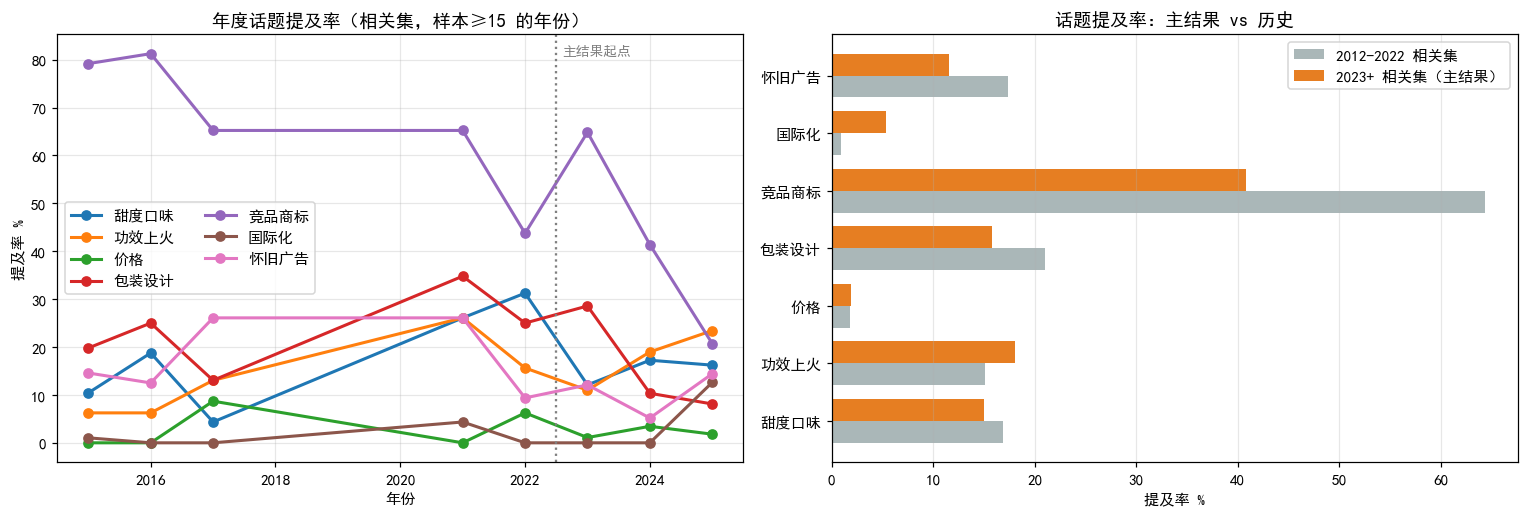

=== 年度话题提及率 %（相关集）===
      样本数  甜度口味  功效上火   价格  包装设计  竞品商标   国际化  怀旧广告
year                                              
2015   96  10.4   6.2  0.0  19.8  79.2   1.0  14.6
2016   16  18.8   6.2  0.0  25.0  81.2   0.0  12.5
2017   23   4.3  13.0  8.7  13.0  65.2   0.0  26.1
2021   23  26.1  26.1  0.0  34.8  65.2   4.3  26.1
2022   32  31.2  15.6  6.2  25.0  43.8   0.0   9.4
2023   91  12.1  11.0  1.1  28.6  64.8   0.0  12.1
2024   58  17.2  19.0  3.4  10.3  41.4   0.0   5.2
2025  111  16.2  23.4  1.8   8.1  20.7  12.6  14.4

=== 话题提及率对比 %（相关集）===
      2012-2022  2023+ 主结果    变化
国际化         0.9        5.4   4.5
功效上火       15.1       18.1   3.0
价格          1.8        1.9   0.1
甜度口味       16.9       15.0  -1.9
包装设计       21.0       15.8  -5.2
怀旧广告       17.4       11.5  -5.8
竞品商标       64.4       40.8 -23.6


In [9]:
TOPICS = {
    '甜度口味': ['甜', '太甜', '糖水', '含糖', '无糖', '低糖', '齁', '腻', '口味', '好喝', '难喝', '味道'],
    '功效上火': ['上火', '降火', '清热', '功效', '去火', '中药', '草本', '凉性', '药味', '养生'],
    '价格':     ['贵', '便宜', '价格', '性价比', '智商税', '划算', '多少钱', '涨价'],
    '包装设计': ['包装', '设计', '罐', '瓶', '颜值', '好看', '红罐', '外观'],
    '竞品商标': ['加多宝', '和其正', '商标', '官司', '分家', '侵权', '纠纷'],
    '国际化':   ['国际罐', 'WALOVI', '海外', '出海', '国外', '外国', '全球', '英文'],
    '怀旧广告': ['广告', '怕上火', '小时候', '童年', '记忆', '以前', '代言', '春晚'],
}

df['topics'] = df['content_clean'].map(
    lambda t: [n for n, kws in TOPICS.items() if any(k in t for k in kws)])
tcols = []
for n in TOPICS:
    col = 't_' + n
    df[col] = df['topics'].map(lambda ts, nn=n: nn in ts)
    tcols.append(col)

rel = df[df['on_topic']]                       # 分母：相关集（全年份）
counts  = rel['year'].value_counts().sort_index()
by_year = (rel.groupby('year')[tcols].mean() * 100)
by_year.columns = list(TOPICS)
by_year = by_year[counts >= 15]
cnt = counts[by_year.index]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for n in TOPICS:
    ax[0].plot(by_year.index, by_year[n], marker='o', lw=2, label=n)
ax[0].axvline(2022.5, color='grey', ls=':', lw=1.5)
ax[0].text(2022.6, ax[0].get_ylim()[1] * 0.95, '主结果起点',
           fontproperties=font, color='grey', fontsize=9)
ax[0].set_title('年度话题提及率（相关集，样本≥15 的年份）', fontproperties=font, fontsize=12)
ax[0].set_xlabel('年份', fontproperties=font)
ax[0].set_ylabel('提及率 %', fontproperties=font)
ax[0].legend(prop=font, fontsize=8, ncol=2)
ax[0].grid(alpha=.3)

pri = rel[rel['recent']][tcols].mean() * 100
ctl = rel[~rel['recent']][tcols].mean() * 100
x, w = np.arange(len(TOPICS)), 0.38
ax[1].barh(x - w / 2, ctl.values, w, label='2012-2022 相关集', color='#AAB7B8')
ax[1].barh(x + w / 2, pri.values, w, label='2023+ 相关集（主结果）', color='#E67E22')
ax[1].set_yticks(x)
ax[1].set_yticklabels(list(TOPICS), fontproperties=font)
ax[1].set_xlabel('提及率 %', fontproperties=font)
ax[1].set_title('话题提及率：主结果 vs 历史', fontproperties=font, fontsize=12)
ax[1].legend(prop=font, fontsize=9)
ax[1].grid(alpha=.3, axis='x')

plt.tight_layout()
plt.savefig(FIG / '02_topic_by_year.png', bbox_inches='tight')
plt.show()

print('=== 年度话题提及率 %（相关集）===')
out = by_year.round(1).copy()
out.insert(0, '样本数', cnt)
print(out.to_string())
print()
print('=== 话题提及率对比 %（相关集）===')
comp = pd.DataFrame({'2012-2022': ctl.round(1).values,
                     '2023+ 主结果': pri.round(1).values,
                     '变化': (pri.values - ctl.values).round(1)},
                    index=list(TOPICS))
print(comp.sort_values('变化', ascending=False).to_string())

## 7. 落盘（供 03 使用）

In [10]:
keep = ['row_id', 'platform', 'keyword', 'created_at', 'year',
        'recent', 'on_topic', 'is_primary',
        'content_clean', 'tokens', 'n_tokens', 'like_count', 'p_pos', 'sentiment']
df_out = df[keep].copy()
df_out['topics'] = df['topics'].map(lambda ts: '|'.join(ts))
p = PROC / 'comments_sentiment.csv'
df_out.to_csv(p, index=False, encoding='utf-8-sig')

print('已写出 :', p, '|', round(p.stat().st_size / 1024, 1), 'KB')
print('列 :', list(df_out.columns))
print()
print('图表 :')
for f in sorted(FIG.glob('02_*.png')):
    print('  -', f.name, round(f.stat().st_size / 1024), 'KB')
print()
print('=== 交付给 03 的三层样本量 ===')
print('主结果 2023+相关集 :', int(df['is_primary'].sum()))
print('对照A  2023+全量   :', int(df['recent'].sum()))
print('对照B  全量        :', len(df))

已写出 : <PROJECT_ROOT>\data\processed\comments_sentiment.csv | 249.7 KB
列 : ['row_id', 'platform', 'keyword', 'created_at', 'year', 'recent', 'on_topic', 'is_primary', 'content_clean', 'tokens', 'n_tokens', 'like_count', 'p_pos', 'sentiment', 'topics']

图表 :
  - 02_noise_impact.png 36 KB
  - 02_ppos_distribution.png 29 KB
  - 02_sentiment_controlA_withnoise.png 44 KB
  - 02_sentiment_controlB_full.png 42 KB
  - 02_sentiment_primary.png 43 KB
  - 02_topic_by_year.png 112 KB

=== 交付给 03 的三层样本量 ===
主结果 2023+相关集 : 260
对照A  2023+全量   : 523
对照B  全量        : 881
